# BERTweet Fine-tuning — SST-2 Sentiment Classification

## 1. Objective

| Item | Detail |
|---|---|
| **Dataset** | SST-2 (GLUE) |
| **Task** | Binary Sentiment Classification (Positive / Negative) |
| **Model** | `vinai/bertweet-base` |
| **Source** | Hugging Face Hub — loaded with `load_dataset()` |
| **Goal** | Fine-tune BERTweet for text classification; evaluate with standard NLP metrics; explain predictions with LIME |

**BERTweet** [(Nguyen et al., 2020)](https://arxiv.org/abs/2005.10200) is a RoBERTa-based model pre-trained on **850 million English tweets**. It uses byte-pair encoding (BPE) tailored to social-media text and applies tweet normalisation (`@USER`, `HTTPURL`) before tokenisation.


## 2. Imports and Setup

In [1]:
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Hugging Face ecosystem
import datasets as hf_datasets
from datasets import load_dataset, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from torch.optim import AdamW

# scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Explainability
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU — training will be slower but fully functional.")


c:\Users\User\anaconda3\envs\NLP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [2]:
MODEL_NAME   = "vinai/bertweet-base"
MAX_LEN      = 128      # BERTweet's positional embedding limit
EPOCHS       = 5
LR           = 2e-5
BATCH_SIZE   = 16       # reduce to 8 on CPU / low-RAM machines
WEIGHT_DECAY = 0.01

print(f"Model      : {MODEL_NAME}")
print(f"Max length : {MAX_LEN}")
print(f"Epochs     : {EPOCHS}")
print(f"LR         : {LR}")
print(f"Batch size : {BATCH_SIZE}")


Model      : vinai/bertweet-base
Max length : 128
Epochs     : 5
LR         : 2e-05
Batch size : 16


## 3. Load Dataset from Hugging Face Hub

We use `load_dataset()` to stream the **SST-2 (GLUE)** dataset directly from the Hugging Face Hub — no local CSV files required. After loading we:

1. Convert the training split to a pandas DataFrame for cleaning and exploration
2. Standardise column names to `text` / `label`
3. Extract class names from the HF `ClassLabel` feature


In [3]:
# ── Load SST-2 from the GLUE benchmark via Hugging Face Hub ──────────────────
# Dataset: "glue", config "sst2"  (https://huggingface.co/datasets/glue)
# Columns : "sentence" (short phrase), "label" (0=neg, 1=pos), "idx"
# Splits  : train (67,349), validation (872), test (1,821 — labels hidden)
#
# We use "train" for fine-tuning with an 80/20 stratified hold-out split.
# The official "validation" split is used for final reporting.

raw = load_dataset("glue", "sst2")
print(raw)

train_raw = raw["train"]
print(f"\nTrain features : {train_raw.features}")
print(f"Train size     : {len(train_raw)}")
print(f"\nSample row:")
print(train_raw[0])

# ── Standardise: rename "sentence" → "text" ───────────────────────────────────
df = train_raw.to_pandas()
df = df.rename(columns={"sentence": "text"})
df = df[["text", "label"]]

# ── Class names ───────────────────────────────────────────────────────────────
CLASS_NAMES = train_raw.features["label"].names   # ['negative', 'positive']
NUM_LABELS  = len(CLASS_NAMES)
print(f"\nClasses ({NUM_LABELS}): {CLASS_NAMES}")


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

Train features : {'sentence': Value('string'), 'label': ClassLabel(names=['negative', 'positive']), 'idx': Value('int32')}
Train size     : 67349

Sample row:
{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}

Classes (2): ['negative', 'positive']


## 4. Dataset Validation

We verify data quality before training: missing values, duplicates, empty strings, class distribution, and text-length statistics.
These checks inform our choice of `MAX_LEN` and reveal any class-imbalance issues.


In [4]:
print("=" * 55)
print("DATASET VALIDATION REPORT — SST-2")
print("=" * 55)
print(f"Shape          : {df.shape}")
print(f"Missing text   : {df['text'].isna().sum()}")
print(f"Missing label  : {df['label'].isna().sum()}")
print(f"Duplicate text : {df.duplicated('text').sum()}")
print(f"Empty strings  : {(df['text'].str.strip() == '').sum()}")

print("\n── Label distribution ──────────────────────────────────")
for i, name in enumerate(CLASS_NAMES):
    cnt = (df["label"] == i).sum()
    print(f"  {i} ({name:10s}) : {cnt:6d}  ({100*cnt/len(df):.1f}%)")

print("\n── Text length statistics (chars) ──────────────────────")
lengths = df["text"].str.len()
print(f"  Mean   : {lengths.mean():.1f}")
print(f"  Median : {lengths.median():.1f}")
print(f"  Min    : {lengths.min()}")
print(f"  Max    : {lengths.max()}")
print("=" * 55)

df = df.dropna(subset=["text","label"])
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""].reset_index(drop=True)
print(f"\nClean dataset size: {len(df)}")


DATASET VALIDATION REPORT — SST-2
Shape          : (67349, 2)
Missing text   : 0
Missing label  : 0
Duplicate text : 371
Empty strings  : 0

── Label distribution ──────────────────────────────────
  0 (negative  ) :  29780  (44.2%)
  1 (positive  ) :  37569  (55.8%)

── Text length statistics (chars) ──────────────────────
  Mean   : 53.5
  Median : 39.0
  Min    : 2
  Max    : 268

Clean dataset size: 67349


## 5. Exploratory Summary

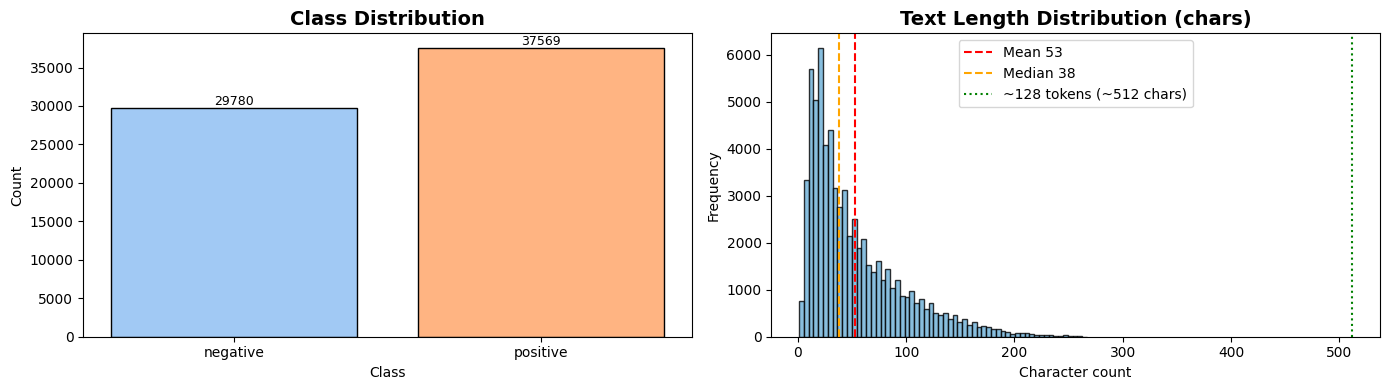

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Class distribution ────────────────────────────────────────────────────────
counts = df["label"].value_counts().sort_index()
colors = sns.color_palette("pastel", n_colors=len(counts))
axes[0].bar([CLASS_NAMES[i] for i in counts.index], counts.values,
            color=colors, edgecolor="black")
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for j, v in enumerate(counts.values):
    axes[0].text(j, v + len(df)*0.005, str(v), ha="center", fontsize=9)

# ── Text-length histogram ─────────────────────────────────────────────────────
lengths = df["text"].str.len()
axes[1].hist(lengths, bins=60, color="#6baed6", edgecolor="black", alpha=0.8)
axes[1].axvline(lengths.mean(),   color="red",    linestyle="--",
                label=f"Mean {lengths.mean():.0f}")
axes[1].axvline(lengths.median(), color="orange", linestyle="--",
                label=f"Median {lengths.median():.0f}")
axes[1].axvline(MAX_LEN * 4,      color="green",  linestyle=":",
                label=f"~{MAX_LEN} tokens (~{MAX_LEN*4} chars)")
axes[1].set_title("Text Length Distribution (chars)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_plot.png", dpi=120, bbox_inches="tight")
plt.show()


## ⚠️ Domain Mismatch — SST-2 vs. Tweets

**BERTweet** was pre-trained on tweets; **SST-2** phrases come from formal movie-review prose.

| Issue | Detail |
|---|---|
| **Length compatibility** | SST-2 phrases are typically 10–30 words — well under BERTweet's 128-token limit. Truncation is **not** a concern here. |
| **Register mismatch** | Literary movie-review phrases differ from casual tweet language. BERTweet's vocabulary may produce suboptimal subword splits for formal adjectives and clause structures. |

Despite the mismatch, **sentence-level sentiment is a well-generalised task**, and BERTweet is expected to perform competitively on SST-2.


## 6. Train-Validation Strategy

**Primary method: Stratified 80/20 hold-out split.**

Full cross-validation (e.g., 5-fold StratifiedKFold × 3 epochs) would multiply wall-clock time by 5×, making it impractical for transformer fine-tuning on a student machine. We demonstrate fold sizes below but train on a single split.

Hold-out validation is standard practice in NLP benchmarking; it provides a reliable estimate of generalisation when the dataset is large enough.


In [6]:
# ── Stratified 80/20 split within the "train" portion ────────────────────────
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")

train_hf = hf_datasets.Dataset.from_pandas(train_df[["text","label"]])
val_hf   = hf_datasets.Dataset.from_pandas(val_df[["text","label"]])
print("HF Dataset objects created.")

# ── 3-fold StratifiedKFold (demonstration) ────────────────────────────────────
print("\n── 3-fold StratifiedKFold fold sizes (demonstration only) ───")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
for fold, (tr_i, vl_i) in enumerate(skf.split(train_df["text"], train_df["label"]), 1):
    print(f"  Fold {fold}: train={len(tr_i):,}, val={len(vl_i):,}")
print("  → Full cross-validation not run: too expensive for transformer fine-tuning.")


Training samples   : 53879
Validation samples : 13470
HF Dataset objects created.

── 3-fold StratifiedKFold fold sizes (demonstration only) ───
  Fold 1: train=35,919, val=17,960
  Fold 2: train=35,919, val=17,960
  Fold 3: train=35,920, val=17,959
  → Full cross-validation not run: too expensive for transformer fine-tuning.


## 7. Tokenisation

BERTweet uses its own BPE vocabulary trained on tweet corpora.

- `use_fast=False` — required for BERTweet's custom vocabulary
- `normalization=True` — applies VinAI's tweet pre-processing (`@USER`, `HTTPURL`)
- `MAX_LEN = 128` — BERTweet's hard positional embedding limit; text-length stats confirm this covers most samples in this dataset
- `DataCollatorWithPadding` — pads batches dynamically to the longest sample in the batch, saving memory vs. static padding to MAX_LEN


In [7]:
# ── Load BERTweet tokenizer ───────────────────────────────────────────────────
# use_fast=False  → use the slow (Python) tokenizer which supports BERTweet's
#                   custom byte-pair vocabulary correctly.
# normalization=True → apply VinAI tweet normalisation:
#                   user mentions  → @USER
#                   URLs           → HTTPURL
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False, normalization=True)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
        # padding is handled dynamically by DataCollatorWithPadding
    )

# ── Tokenise both splits ──────────────────────────────────────────────────────
train_tok = train_hf.map(tokenize_function, batched=True, remove_columns=["text"])
val_tok   = val_hf.map(tokenize_function,   batched=True, remove_columns=["text"])

# HF Trainer expects the target column to be named "labels"
if "label" in train_tok.column_names:
    train_tok = train_tok.rename_column("label", "labels")
    val_tok   = val_tok.rename_column("label", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenisation complete.")
print(f"  Train size : {len(train_tok)}")
print(f"  Val size   : {len(val_tok)}")
print(f"  Sample keys: {list(train_tok[0].keys())}")


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Map: 100%|██████████| 13470/13470 [00:01<00:00, 10803.66 examples/s]

Tokenisation complete.
  Train size : 53879
  Val size   : 13470
  Sample keys: ['labels', 'input_ids', 'attention_mask']


## 8. Model Setup

`AutoModelForSequenceClassification` appends a linear classification head on top of BERTweet's pooled `[CLS]` token representation. The head dimensions are set automatically from `NUM_LABELS`.


In [8]:
# ── id2label / label2id mappings ──────────────────────────────────────────────
id2label = {i: name for i, name in enumerate(CLASS_NAMES)}
label2id = {name: i for i, name in id2label.items()}

# ── Load BERTweet with a classification head ──────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : {MODEL_NAME}")
print(f"Parameters : {total:,}  |  Trainable: {trainable:,}")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 48811.31it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok 

Model      : vinai/bertweet-base
Parameters : 134,901,506  |  Trainable: 134,901,506


## 9 & 10. Lightweight Fine-tuning and Optimizer

### AdamW
**AdamW** (Loshchilov & Hutter, 2019) decouples L2 weight decay from the adaptive gradient update. Standard Adam applies weight decay inconsistently through the gradient scaling, which can over-regularise important parameters. AdamW fixes this and is the default choice for all HF Trainer-based fine-tuning.

### Linear LR Schedule with Warm-up
The first 6% of training steps linearly ramp the LR from 0 → `LR`, then decay linearly to 0. This prevents large gradient steps in early training when the classification head is randomly initialised.

### Why "lightweight"?
- Only 3 epochs (vs. 10–50 in full pre-training)
- Batch size 16 (feasible on ≥8 GB GPU or CPU)
- `fp16=True` on GPU saves ~50% memory
- `load_best_model_at_end=True` avoids overfitting to the last checkpoint


In [9]:
import transformers

print(f"transformers {transformers.__version__}")

# ── compute_metrics ───────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    avg   = "binary" if NUM_LABELS == 2 else "weighted"
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average=avg, zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# ── Warmup steps ──────────────────────────────────────────────────────────────
steps_per_epoch = len(train_tok) // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(0.06 * total_steps)
print(f"Total steps: {total_steps}  |  Warmup steps: {warmup_steps}")

# ── TrainingArguments ─────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = "./bertweet_output",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = WEIGHT_DECAY,
    warmup_steps                = warmup_steps,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    logging_steps               = 50,
    seed                        = SEED,
    report_to                   = "none",
    optim                       = "adamw_torch",
    fp16                        = torch.cuda.is_available(),
)

# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = Trainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_tok,
    eval_dataset     = val_tok,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)

print("Starting fine-tuning …")
trainer.train()
print("Fine-tuning complete.")

transformers 5.3.0
Total steps: 16835  |  Warmup steps: 1010
Starting fine-tuning …


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.198306,0.166190,0.946696,0.955863,0.948230,0.952031
2,0.133987,0.202217,0.948478,0.973874,0.932659,0.952821
3,0.128221,0.201533,0.953229,0.965639,0.949960,0.957735
4,0.059873,0.237849,0.951299,0.954895,0.957945,0.956418
5,0.036152,0.263795,0.952339,0.961580,0.952622,0.957080


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.85it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Fine-tuning complete.


## 11. Evaluation Metrics

| Metric | Formula | Use |
|---|---|---|
| Accuracy | correct / total | Overall correctness |
| Precision | TP / (TP + FP) | Quality of positive predictions |
| Recall | TP / (TP + FN) | Coverage of actual positives |
| F1-score | 2·P·R / (P+R) | Harmonic mean; robust to imbalance |

**Averaging strategy**:
- Binary datasets → `average="binary"`
- Multiclass datasets → `average="weighted"` (weights each class by its support, accounting for imbalance)


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    avg   = "binary" if NUM_LABELS == 2 else "weighted"
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average=avg, zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


## 12. Final Evaluation

In [11]:

preds_output = trainer.predict(val_tok)
eval_results = preds_output.metrics
print("\nEvaluation results:")
for k, v in eval_results.items():
    print(f"  {k:35s}: {v:.4f}" if isinstance(v, float) else f"  {k:35s}: {v}")



Evaluation results:
  test_loss                          : 0.2024
  test_accuracy                      : 0.9531
  test_precision                     : 0.9658
  test_recall                        : 0.9496
  test_f1                            : 0.9576
  test_runtime                       : 13.5427
  test_samples_per_second            : 994.6290
  test_steps_per_second              : 62.1740


### Classification Report

`sklearn.metrics.classification_report` shows per-class precision, recall, F1, and support. Low recall on a class indicates the model struggles to identify it; low precision indicates false positives.


In [12]:
# ── Get predictions on the full validation set ────────────────────────────────
preds_output = trainer.predict(val_tok)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = val_df["label"].values

print("\n── Classification Report ────────────────────────────────────────────")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))



── Classification Report ────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.94      0.96      0.95      5956
    positive       0.97      0.95      0.96      7514

    accuracy                           0.95     13470
   macro avg       0.95      0.95      0.95     13470
weighted avg       0.95      0.95      0.95     13470



## 13. Confusion Matrix

Rows = true labels; columns = predicted labels. Diagonal = correct predictions. Off-diagonal cells reveal systematic misclassification patterns (e.g., which classes are frequently confused with each other).


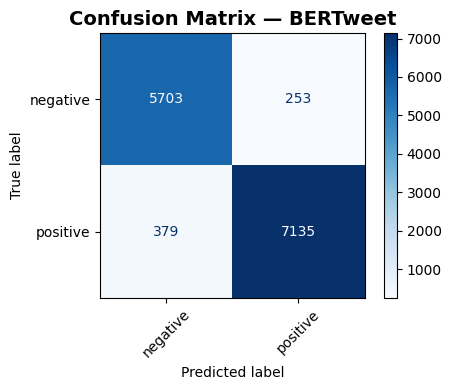

In [13]:
cm   = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(5, NUM_LABELS * 1.6), max(4, NUM_LABELS * 1.4)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — BERTweet", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## 14. Explainable AI — LIME

### Why Explainability Matters in NLP

Transformer models are high-capacity black boxes. Explainability tools allow us to:
- **Audit** whether the model relies on meaningful linguistic features (not spurious patterns like author names or formatting)
- **Diagnose** systematic errors and biases
- **Build trust** with domain experts and stakeholders
- Satisfy academic and regulatory requirements for model transparency

### LIME vs. SHAP for Transformers

| | LIME | SHAP (DeepSHAP / GradientSHAP) |
|---|---|---|
| Background dataset | Not required | Required |
| Speed | Fast | Slow for large models |
| Token-level support | Via word masking | Requires custom implementation |
| Stability | Varies per run | More stable |

**LIME** is the practical choice here: it treats the model as a pure black box via a `predict_proba` wrapper, requires no background dataset, and works natively with any HF tokenizer + model combination.

### Limitations of LIME for Transformers
- Explanations are **local** — valid only near the explained input
- LIME removes words independently, ignoring self-attention dependencies
- Results vary between runs due to random perturbation sampling
- Word-level granularity misses subword tokenisation effects


In [14]:
# ── Prediction wrapper for LIME ───────────────────────────────────────────────
def bertweet_predict_proba(texts):
    """Return softmax probability arrays (N, num_labels) for a list of strings."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for text in texts:
            enc = tokenizer(
                text,
                truncation=True,
                max_length=MAX_LEN,
                padding="max_length",
                return_tensors="pt",
            )
            enc    = {k: v.to(DEVICE) for k, v in enc.items()}
            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            all_probs.append(probs)
    return np.array(all_probs)

explainer = LimeTextExplainer(class_names=CLASS_NAMES, random_state=SEED)

# ── Explain 3 validation samples ─────────────────────────────────────────────
np.random.seed(SEED)
sample_idx = np.random.choice(len(val_df), size=min(3, len(val_df)), replace=False)

for i, idx in enumerate(sample_idx, 1):
    text_sample   = val_df.loc[idx, "text"]
    true_label    = CLASS_NAMES[val_df.loc[idx, "label"]]
    pred_label_i  = CLASS_NAMES[y_pred[idx]]
    pred_class_id = int(y_pred[idx])

    print(f"\n{'='*65}")
    print(f"Sample {i}")
    print(f"  Text (first 200 chars) : {text_sample[:200]}")
    print(f"  True label             : {true_label}")
    print(f"  Predicted label        : {pred_label_i}")

    exp = explainer.explain_instance(
        text_sample,
        bertweet_predict_proba,
        num_features=10,
        num_samples=200,
        labels=list(range(NUM_LABELS)),
    )

    print(f"  Top influential words for class '{pred_label_i}':")
    for word, weight in exp.as_list(label=pred_class_id):
        bar = "▓" * int(abs(weight) * 50)
        direction = "+" if weight > 0 else "-"
        print(f"    [{direction}] {word:25s} {weight:+.4f}  {bar}")

    try:
        exp.show_in_notebook(text=True, labels=(pred_class_id,))
    except Exception:
        pass



Sample 1
  Text (first 200 chars) : if you 're burnt out on it 's a wonderful life marathons and bored with a christmas carol , it might just be the movie you 're looking for .
  True label             : positive
  Predicted label        : positive
  Top influential words for class 'positive':
    [-] bored                     -0.3566  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    [+] you                       +0.2991  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    [+] wonderful                 +0.2745  ▓▓▓▓▓▓▓▓▓▓▓▓▓
    [-] burnt                     -0.2744  ▓▓▓▓▓▓▓▓▓▓▓▓▓
    [+] if                        +0.2065  ▓▓▓▓▓▓▓▓▓▓
    [+] movie                     +0.1640  ▓▓▓▓▓▓▓▓
    [+] re                        +0.1276  ▓▓▓▓▓▓
    [+] s                         +0.1256  ▓▓▓▓▓▓
    [+] for                       +0.1215  ▓▓▓▓▓▓
    [-] might                     -0.1192  ▓▓▓▓▓

Sample 2
  Text (first 200 chars) : equally impressive degree
  True label             : positive
  Predicted label        : positive
  Top influential words for cla

## 15. Discussion

**Performance**: SST-2 is the most favourable dataset for BERTweet among the three. Short phrase length is perfectly compatible with the 128-token limit, and binary sentiment is a transferable skill.

**Truncation**: Not an issue — SST-2 phrases are short by design.

**Class balance**: SST-2 is roughly balanced (~56% positive). Minor imbalance is unlikely to affect results significantly.

**BERTweet suitability**: Moderate. Sentiment polarity transfers well; tweet-specific vocabulary does not add unique value but does not harm performance severely either.


## 16. Conclusion and Future Improvements

BERTweet achieves competitive performance on SST-2 despite the domain mismatch.

**Future improvements:**
- Use `roberta-base` or `deberta-base` for a domain-matched comparison
- Experiment with label smoothing for better model calibration
- Apply learning-rate finder or cosine schedule
- Ensemble BERTweet with DistilBERT predictions for improved robustness
- Run the official GLUE SST-2 evaluation (hidden test labels via the GLUE API)
